# Logistic Regression SOPP with Visualization

In [ ]:
# Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


In [ ]:
sopp_df = pd.read_csv("sopp_inflated.csv")

In [ ]:
# Turn Year and Month into Categories
sopp_df['YEAR'] = sopp_df['YEAR'].astype('category')
sopp_df['MONTH'] = sopp_df['MONTH'].astype('category')

In [ ]:
sopp_df.head()

,date,time_segment,precinct,DAY_WEEK,STOP,YEAR,MONTH
0,2010-01-01,Late Night,CENTRAL,Friday,1,2010,1
1,2010-01-01,Late Night,EAST,Friday,1,2010,1
2,2010-01-01,Late Night,HERMITAGE,Friday,1,2010,1
3,2010-01-01,Late Night,MADISON,Friday,1,2010,1
4,2010-01-01,Late Night,MIDTOWN HILLS,Friday,1,2010,1


## Model with Precinct

In [ ]:
# Sort by time
sopp_df = sopp_df.sort_values("date")

X = pd.get_dummies(sopp_df[['precinct', 'DAY_WEEK', 'time_segment', 'MONTH', 'YEAR']])

# manually drop "average" columns
cols_to_drop = [
    'precinct_SOUTHEAST',
    'DAY_WEEK_Tuesday',
    'time_segment_Morning',
    'MONTH_1',
    'YEAR_2010'
]

X = X.drop(columns=cols_to_drop)

# Target
y = sopp_df['STOP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
pre_model = LogisticRegression(max_iter=1000, class_weight = "balanced")
pre_model.fit(X_train, y_train)

y_prob = pre_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

### Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.73      0.37      3971
           1       0.96      0.73      0.83     32425

    accuracy                           0.73     36396
   macro avg       0.60      0.73      0.60     36396
weighted avg       0.88      0.73      0.78     36396



### ROC AUC

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

np.float64(0.802055643585618)

### Confusion Matrix

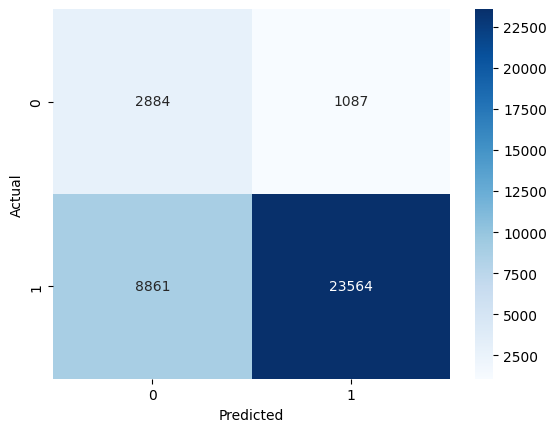

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance Odds Ratio

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': pre_model.coef_[0],
    'Odds_Ratio': np.exp(pre_model.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
6               precinct_SOUTH     1.231927    3.427827
4       precinct_MIDTOWN HILLS     1.204455    3.334942
1                precinct_EAST     1.048050    2.852086
31                   YEAR_2012     0.953847    2.595675
32                   YEAR_2013     0.871072    2.389470
2           precinct_HERMITAGE     0.787900    2.198773
33                   YEAR_2014     0.549403    1.732218
7                precinct_WEST     0.519447    1.681098
30                   YEAR_2011     0.408781    1.504982
18          time_segment_Night     0.331361    1.392863
13          DAY_WEEK_Wednesday     0.265084    1.303541
5               precinct_NORTH     0.247337    1.280610
0             precinct_CENTRAL     0.212306    1.236526
21                     MONTH_4     0.152286    1.164493
16        time_segment_Evening     0.119218    1.126615
20                     MONTH_3     0.100622    1.105858
23                     MONTH_6     0.060468    1

### Visualization of the Feature Importance

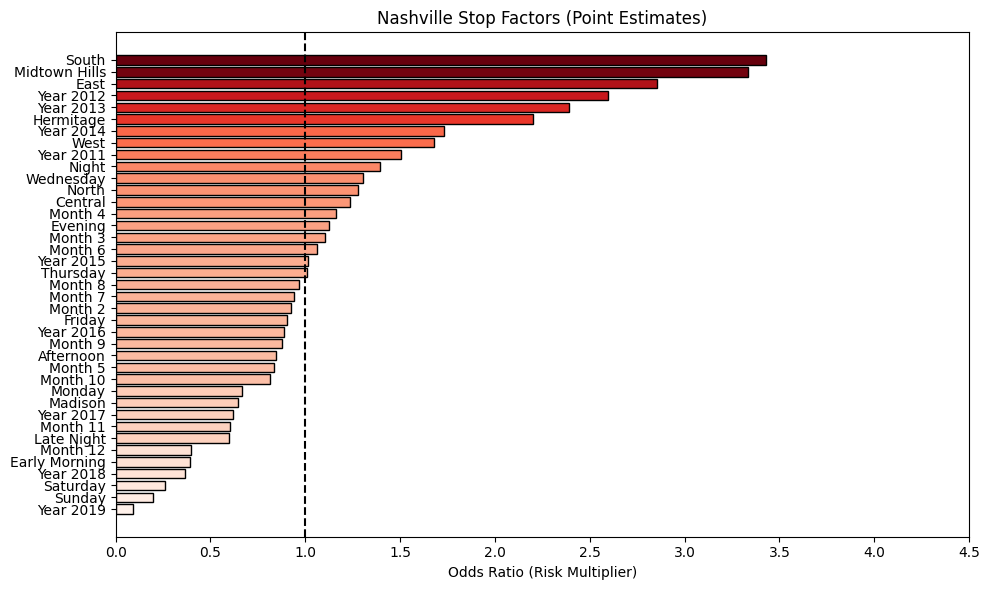

In [ ]:
feature_importance['displayname'] = (feature_importance['Feature']
                             .str.replace('precinct_', '', case=False)
                             .str.replace('DAY_WEEK_', '', case=False)
                             .str.replace('MONTH_NAME_', '', case=False)
                             .str.replace('time_segment_', '', case=False)
                             .str.replace('_', ' ')
                             .str.title())


plt.figure(figsize=(10, 6))

feature_importance = feature_importance.sort_values("Odds_Ratio")

# Using a color map to emphasize the high-risk zones
colors = plt.cm.Reds(feature_importance['Odds_Ratio'] / feature_importance['Odds_Ratio'].max())

plt.barh(feature_importance['displayname'], feature_importance['Odds_Ratio'], color=colors, edgecolor='black')
plt.axvline(x=1, color='black', linestyle='--', label='Baseline (No Effect)')

# Annotate the actual OR values on the bars
# for i, v in enumerate(feature_importance['Odds_Ratio']):
#     plt.text(v + 0.15, i, str(v), va='center')

plt.xlabel('Odds Ratio (Risk Multiplier)')
plt.title('Nashville Stop Factors (Point Estimates)')
plt.xlim(0, 4.5)
plt.tight_layout()
plt.show()